<a href="https://colab.research.google.com/github/jssjvls7-cpu/Taller-PMP/blob/main/Taller_PMP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Taller: Precipitación Máxima Probable**
Autora: Jocelyn Lugo Soza

El presente taller tiene como objetivo estructurar el algoritmo de cálculo para la estimación de la Precipitación Máxima Probable (PMP) en una cuenca. Se utiliza el método hidrometeorológico, particularmente el método local, considerando como caso estudio la cuenca del río Maipo.

Los datos utilizados corresponden a variables atmosféricas del reanálisis del Centro Europeo de Previsiones Meteorológicas a Plazo Medio (ECMWF), ERA5.

Se incluye la configuración del ambiente para .


**Estructura Metodológica:**

*   [Configuración Inicial](#configuracion-inicial)
*   [Abrir Archivos de Datos](#carga-datos)
*   [Estimación PMP - Método Hidrometeorológico](#estimacion-pmp)

<a id="configuracion-inicial"></a>
# Configuración Inicial
En Python, las librerías esenciales para desarrollar este tipo de trabajos corresponden a las necesarias para el análisis espacial (xarray, netcdf4, geopandas, rioxarray), las necesarias para el manejo de cálculos y matrices (pandas, numpy) y, para facilitar la visualización, las requeridas para generar representaciones gráficas de los datos (pyplot, cartopy).

In [1]:
# ==============================================================================
# PREPARACIÓN DEL ENTORNO
# ==============================================================================

import sys
import time
import subprocess

start_time = time.time()

# Función para generar una barra de progreso
def actualizar_barra(porcentaje, tarea):
    largo_barra = 40
    lleno = int(largo_barra * porcentaje / 100)
    barra = '█' * lleno + '-' * (largo_barra - lleno)
    sys.stdout.write(f'\r[{barra}] {porcentaje:3d}% | {tarea:<40}')
    sys.stdout.flush()

actualizar_barra(0, "Iniciando configuración...")

# Definición de paquetes a instalar
pasos_instalacion = [
    (["xarray", "netcdf4"], "Instalando manejo de NetCDF..."),
    (["geopandas", "rioxarray", "cartopy"], "Instalando librerías espaciales..."),
    (["plotly", "nbformat"], "Instalando librerías para representación 3D...")
]

# Ejecución de instalaciones
progreso_actual = 10
actualizar_barra(progreso_actual, "Actualizando gestor de paquetes...")
subprocess.run(["pip", "install", "--upgrade", "pip", "-q"])

for paquetes, mensaje in pasos_instalacion:
    progreso_actual += 25
    actualizar_barra(progreso_actual, mensaje)
    subprocess.run(["pip", "install", "-q"] + paquetes)

progreso_actual = 90
actualizar_barra(progreso_actual, "Importando módulos en memoria...")

# Importación de librerías base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from scipy.stats import genextreme
from scipy.optimize import curve_fit
from matplotlib.gridspec import GridSpec

# Importación de herramientas espaciales y climáticas
import xarray as xr
import geopandas as gpd
import rioxarray

# Importar librerías para graficar
import plotly.graph_objects as go
import cartopy.crs as ccrs
import cartopy.feature as cfeature


actualizar_barra(100, "Entorno configurado correctamente.")

end_time = time.time()
tiempo_total = round(end_time - start_time, 1)

print(f"\n\nProceso finalizado. Tiempo total de ejecución: {tiempo_total} segundos.")

[████████████████████████████████████████] 100% | Entorno configurado correctamente.      

Proceso finalizado. Tiempo total de ejecución: 36.6 segundos.


<a id="carga-datos"></a>
# Abrir archivos de datos



In [2]:
# ==============================================================================
# CONEXIÓN A DRIVE
# ==============================================================================
from google.colab import drive

# Ruta global
drive.mount('/content/drive')
carpeta = '/content/drive/MyDrive/Colab Notebooks/Datos taller'


### Datos

# Mayores tormentas históricas reanálisis ERA5-Land (pr ERA5-Land)
ds_pr = xr.open_dataset(f'{carpeta}/tormentas.nc')

# Registros históricos de precipitación en estaciones pluviométricas
ds_estaciones = xr.open_dataset(f'{carpeta}/pr_CR2.nc')

# Cuenca del río Maipo: shapefile y máscara
shp_cuenca = gpd.read_file(f'{carpeta}/shp/Maipo.shp') # Archivo shapefile de la cuenca del río Maipo
shp_cuenca = shp_cuenca.to_crs("EPSG:4326") # crs del shapefile
ds_pr = ds_pr.rio.write_crs("EPSG:4326") # Indicar crs para el dataset (permite recortar con el archivo shp)

mascara_cuenca = xr.open_dataset(f'{carpeta}/mascara/Maipo.nc') # Máscara binaria

# Humedad en niveles de presión
ds_humedad = xr.open_dataset(f"{carpeta}/humedad_19840705.nc")

# Serie de tiempo de agua precipitable para una celda
ds_pw_serie = xr.open_dataset(f"{carpeta}/pw_ejemplo.nc")
ds_pw_serie = ds_pw_serie.where(ds_pw_serie.time.dt.year!=2001, drop=True) # No considerar datos de 2001 debido a un error en el reanálisis

# Valores grillados de pw y pw_sat en el espacio para las tormentas consideradas
ds_pw_tormentas = xr.open_dataset(f"{carpeta}/pw_tormentas.nc")

# Valores de pw_100 ya calculados
ds_pw_100 = xr.open_dataset(f"{carpeta}/pw_horzv10.nc")

Mounted at /content/drive


<a id="estimacion-pmp"></a>
# Estimación PMP - Método Hidrometeorológico

**Zona de Estudio**

La zona de estudio considerada para el taller corresponde a la cuenca del río Maipo, que se superpone casi en su totalidad al territorio de la región Metropolitana. Esta cuenca es de especial interés, en primer lugar, debido a la gran cantidad de registros históricos que posee, y, por otro lado, debido a la alta densidad de población que alberga en sus áreas urbanas, convirtiéndola en un lugar crítico desde el punto de vista hidrológico.

Algunas características relevantes de esta cuenca:

* Superficie total: 15,274 [$km^2$]
* Clima: Templado de tipo mediterráneo con estación seca prolongada (a excepción de la cordillera)
* Precipitación media anual: aproximadamente 300 [$mm$]
* Caudal medio: 145.7 [$m^3/s$]


Las mayores precipitaciones observadas (en estaciones pluviométricas) dentro de la cuenca corresponden a:

* 24h: 336.9 [$mm$], en Valle Olivares (2018-07-17, cordillera).
* 48h: 418.0 [$mm$], en Embalse El Yeso (2000-06-13).
* 72h: 528 [$mm$], en Estación Caleu (1987-07-14).


/usr/local/lib/python3.13/dist-packages/xarray/core/dataarray.py:6446: FutureWarning:

Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().

/usr/local/lib/python3.13/dist-packages/xarray/core/dataarray.py:6446: FutureWarning:

Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().

/usr/local/lib/python3.13/dist-packages/xarray/core/dataarray.py:6446: FutureWarning:

Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().



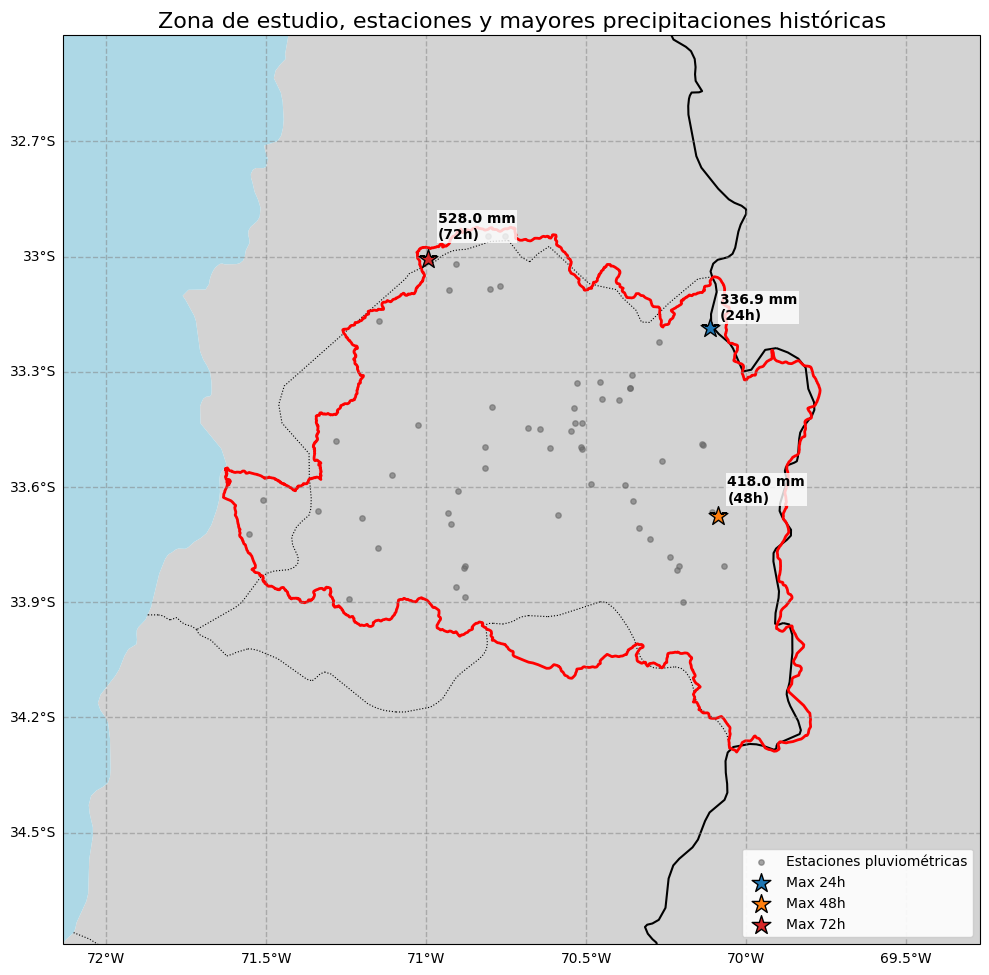

In [18]:
### Imagen Zona de Estudio


## Filtrar estaciones dentro de la cuenca

# Convertir cuencas a serie de pandas para filtrar
serie_cuencas = ds_estaciones['cuenca'].to_series()

# Filtrar cuencas que contengan: "rio Maipo"
codigos_maipo = serie_cuencas[serie_cuencas.str.contains('rio Maipo', case=False, na=False)].index

# Seleccionar cuencas encontradas
ds_maipo = ds_estaciones.sel(codigo=codigos_maipo)


## Cálculo de precipitaciones máximas históricas para 24h, 48h y 72h

# Búsqueda de valores
duraciones = {1: '24h', 2: '48h', 3: '72h'}
maximos_historicos = {}

pr_data = ds_maipo['pr']

for d, etiqueta in duraciones.items():
    # Suma móvil temporal
    pr_roll = pr_data.rolling(fecha=d, center=False).sum()

    # Valor máximo para la ventana
    max_val = float(pr_roll.max(skipna=True))

    # Índice del máximo
    idx_plano = int(pr_roll.argmax(skipna=True))
    idx_fecha, idx_codigo = np.unravel_index(idx_plano, pr_roll.shape)

    # Recuperar los datos
    codigo_max = ds_maipo['codigo'].values[idx_codigo]
    fecha_max = ds_maipo['fecha'].values[idx_fecha]
    lat_max = float(ds_maipo['lat'].sel(codigo=codigo_max))
    lon_max = float(ds_maipo['lon'].sel(codigo=codigo_max))

    maximos_historicos[d] = {
        'etiqueta': etiqueta,
        'valor': max_val,
        'lat': lat_max,
        'lon': lon_max,
        'fecha': fecha_max,
        'nombre': str(ds_maipo['nombre'].sel(codigo=codigo_max).values)
    }


## Gráfico zona de estudio

# Generar figura y ejes
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Establecer límites del mapa
bounds = shp_cuenca.total_bounds
ax.set_extent([bounds[0] - 0.5, bounds[2] + 0.5, bounds[1] - 0.5, bounds[3] + 0.5], crs=ccrs.PlateCarree())

# Capa 1: Tierra y Mar
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=0)

# Capa 2: Límites internacionales y regionales
ax.add_feature(cfeature.BORDERS, linewidth=1.5, edgecolor='black', zorder=1)
regiones = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lines', scale='10m', facecolor='none')
ax.add_feature(regiones, edgecolor='black', linewidth=0.8, linestyle=':', zorder=1)

# Capa 3: Límites de la cuenca
shp_cuenca.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=2, transform=ccrs.PlateCarree(), zorder=2)

# Capa 4: Ubicación de las estaciones dentro de la cuenca
ax.scatter(ds_maipo['lon'], ds_maipo['lat'],
           color='dimgray', s=15, alpha=0.6, transform=ccrs.PlateCarree(),
           zorder=3, label='Estaciones pluviométricas')

# Capa 5: Estaciones con mayor precipitación histórica
colores_max = {1: '#1f77b4', 2: '#ff7f0e', 3: '#d62728'} # Azul, Naranja, Rojo

for d, info in maximos_historicos.items():
    # Marcador
    ax.scatter(info['lon'], info['lat'],
               color=colores_max[d], edgecolors='black', marker='*', s=200,
               transform=ccrs.PlateCarree(), zorder=4, label=f"Max {info['etiqueta']}")

    # Texto con el valor en mm
    texto = f"{info['valor']:.1f} mm\n({info['etiqueta']})"
    ax.text(info['lon'] + 0.03, info['lat'] + (d * 0.015), texto,
            transform=ccrs.PlateCarree(), fontsize=10, fontweight='bold',
            color='black', ha='left', va='bottom', zorder=5,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

# Grilla y Ejes
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=["bottom", "left"],
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')

ax.set_title('Zona de estudio, estaciones y mayores precipitaciones históricas', fontsize=16)
ax.legend(loc='lower right', framealpha=0.9)

plt.tight_layout()
plt.show()

**Datos**

Para la estimación de la PMP de forma espacial se utilizarán datos de reanálisis, específicamente, de las bases de datos del Centro Europeo de Previsiones a Plazo Medio (ECMWF, por sus siglas en inglés), ERA5.

Las bases de datos utilizadas corresponden a:

* ERA5 en niveles de presión (Hersbach *et al.*, 2020) para valores de humedad en altura (q, RH).
* ERA5-Land (Muñoz Sabater, 2019) para precipitación en superficie (pr).

**Método Local**

La estimación de la PMP por el método local se basa en la suposición de que, para tormentas de alta eficiencia (tormentas con una gran capacidad para transformar humedad atmosférica en precipitación líquida), la precipitación total es directamente proporcional a la cantidad de humedad disponible en la atmósfera. Matemáticamente, esta relación se puede establecer como:

$\frac{pr_1}{pw_1} = \frac{pr_2}{pw_2}$

De esta forma, la mayor precipitación esperable ocurrirá cuando el contenido de humedad sea el máximo permitido por las condiciones atmosféricas locales. Esto corresponde a la definición de PMP, por lo que podemos escribir:

$\frac{PMP}{pw_{max}} = \frac{pr_1}{pw_1}$

O, de otra forma:

$PMP = pr_{obs}\cdot \frac{pw_{max}}{pw_{obs}}$

Donde $pr$ corresponde a la precipitación acumulada durante una tormenta de alta eficiencia y $pw$ al agua precipitable disponible durante su ocurrencia.

El cociente $pw_{max}/pw_{obs}$ corresponde al Factor de Maximización de Humedad ($r$), por lo que este método es conocido también como Maximización de Humedad.

**Método Local − Tormentas**

La estimación de la PMP por el método local requiere contar con un conjunto de tormentas de alta eficiencia, ya que para esta clase de eventos se cumple la suposición de que la precipitación es proporcional a la cantidad de agua precipitable disponible.

Para este ejemplo, se consideran las precipitaciones ocurridas durante las siguientes tormentas:


*   1980-04-07
*   1982-06-23
*   **1984-07-01**
*   1987-07-12
*   1997-06-19
*   2000-06-11
*   2001-07-16
*   2002-06-01

Para explicar el detalle de la implementación, se mostrará el desarrollo del cálculo para la tormenta de julio del año 1984:

In [4]:
### Seleccionar tormenta espacial ejemplo
tormenta_ej = ds_pr['pr'].sel(tormenta='1984-07-01', duracion=24)

print(tormenta_ej.time.values)

1984-07-05T03:00:00.000000000


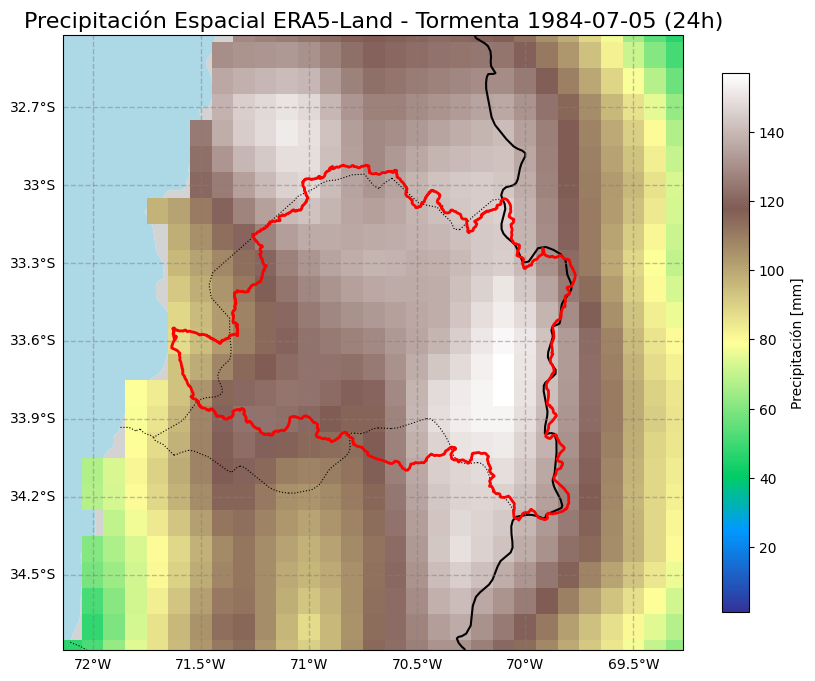

In [5]:
### Gráfico de precipitación espacial

# Generar figura y ejes
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Establecer límites del mapa para la cuenca del río Maipo
bounds = shp_cuenca.total_bounds
ax.set_extent([bounds[0] - 0.5, bounds[2] + 0.5, bounds[1] - 0.5, bounds[3] + 0.5], crs=ccrs.PlateCarree())

# Capa 1: Tierra y Mar (Fondo)
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=0)

# Capa 2: Precipitación espacial ('terrain')
mesh = ax.pcolormesh(
    tormenta_ej.lon,
    tormenta_ej.lat,
    tormenta_ej,
    transform=ccrs.PlateCarree(),
    cmap='terrain',
    zorder=1
)
plt.colorbar(mesh, ax=ax, label='Precipitación [mm]', shrink=0.7, pad=0.05)

# Capa 3: Límites internacionales y regionales
ax.add_feature(cfeature.BORDERS, linewidth=1.5, edgecolor='black', zorder=2)
regiones = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lines', scale='10m', facecolor='none')
ax.add_feature(regiones, edgecolor='black', linewidth=0.8, linestyle=':', zorder=2)

# Capa 4: Límites de la cuenca (¡Ahora sí se visualizará!)
shp_cuenca.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=2, transform=ccrs.PlateCarree(), zorder=3)

# Agregar grilla
gl = ax.gridlines(crs=ccrs.PlateCarree(),
                  draw_labels=["bottom", "left"],
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')

# Agregar título y mostrar figura
ax.set_title('Precipitación Espacial ERA5-Land - Tormenta 1984-07-05 (24h)', fontsize=16)
plt.show()

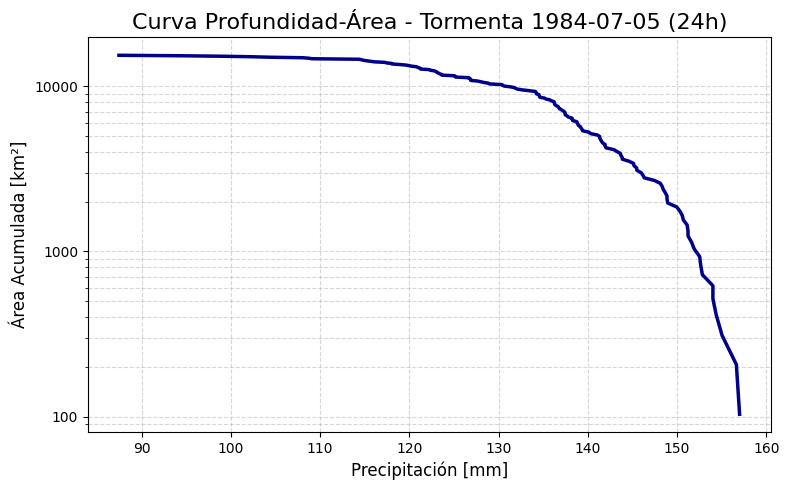

In [6]:
### Curva profundidad-área (P-A) para la tormenta de ejemplo


## Calcular la curva P-A

# Confirmar dimensiones del dataset para rioxarray
if "lon" in tormenta_ej.dims:
    tormenta_ej = tormenta_ej.rio.set_spatial_dims(x_dim="lon", y_dim="lat")

# Recortar precipitación espacial con la cuenca del río Maipo
pr_recortada = tormenta_ej.rio.clip(shp_cuenca.geometry, shp_cuenca.crs, drop=True)

# Ordenar de mayor a menor
pr_vals = pr_recortada.values.flatten() # Convierte la matriz de precipitación espacial a un vector
pr_vals = pr_vals[~np.isnan(pr_vals)] # Eliminar valores NaN
pr_sorted = np.sort(pr_vals)[::-1]

# Área de la cuenca
resolucion_grados = abs(float(tormenta_ej.lon[1] - tormenta_ej.lon[0]))
lat_media = np.abs(float(pr_recortada.lat.mean())) # El área de una celda de grilla depende de la latitud

dx_km = resolucion_grados * 111.32 * np.cos(np.radians(lat_media))
dy_km = resolucion_grados * 111.32
area_celda_km2 = dx_km * dy_km

area_acumulada = np.arange(1, len(pr_sorted) + 1) * area_celda_km2 # Generar el arreglo de área acumulada


## Generar gráfico de curva P-A

# Generar figura y ejes
fig, ax2 = plt.subplots(figsize=(8, 5))

ax2.plot(pr_sorted, area_acumulada, color='darkblue', linewidth=2.5)

ax2.set_xlabel('Precipitación [mm]', fontsize=12)
ax2.set_ylabel('Área Acumulada [km²]', fontsize=12)
ax2.set_title('Curva Profundidad-Área - Tormenta 1984-07-05 (24h)', fontsize=16)

# Escala logarítmica para el Eje Y
ax2.set_yscale('log')

# Forzar marcas (ticks) cada 500 km^2 en una escala logarítmica y formato numérico normal
# ax2.yaxis.set_major_locator(ticker.MultipleLocator(500))
ax2.yaxis.set_major_formatter(ticker.ScalarFormatter())

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

**Método Local − Agua precipitable**

Tras identificar las mayores tormentas para la zona de estudio, es necesario maximizarlas para obtener la PMP. Para esto, es fundamental el cálculo del agua precipitable disponible durante la tormenta, $pw_{obs}$, y el valor de agua precipitable máximo posible durante su ocurrencia, $pw_{max}$.

El agua precipitable se define como la altura de agua líquida que resultaría de condensarse la totalidad de la humedad atmosférica en una columna de aire. Es posible calcular este valor con la fórmula:

$$pw = \frac{1}{g\rho_w} \int_{p_1}^{p_2} q \, dp$$

Esto corresponde a integrar la humedad específica ($q$) a lo largo del perfil vertical de presiones, donde $p_1$ y $p_2$ representan los límites inferior (superficie) y superior de la atmósfera.

Existen dos alternativas para obtener este valor:

* Contar con mediciones continuas de humedad específica ($q$) en altura. Si bien este tipo de mediciones son extremadamente escasas (requiriendo el uso de radiosondas o *dropsonde*), esta alternativa es posible gracias a las bases de datos de reanálisis.
* Estimar el valor a partir de mediciones en superficie de temperatura de rocío ($T_r$). Esta alternativa implica suponer una cierta variación de temperatura constante en altura (gradiente adiabático seco) y presión atmosférica hidrostática, por lo que su uso implica un nivel de incertidumbre no despreciable.

En este caso, se consdiera el uso de variables en altura del reanálisis ERA5 en niveles de presión desde superficie (1,000 [$hPa$]) hasta los 250 [$hPa$]. Este set de datos corresponde a una estructura tridimensional de información espacial como se muestra a continuación:



In [7]:
### Gráfico 3D de campos de humedad


## Datos para los gráficos

# Dimensiones
lon = ds_humedad.longitude.values
lat = ds_humedad.latitude.values
level = ds_humedad.level.values

# Aplanar datos para procesar
L, Y, X = np.meshgrid(level, lat, lon, indexing='ij')
x_flat, y_flat, z_flat = X.flatten(), Y.flatten(), L.flatten()

q_flat = ds_humedad['q'].values.flatten()
r_flat = ds_humedad['r'].values.flatten()


## Humedad específica

# Filtrar 10% más bajo
q_min = np.nanpercentile(q_flat, 10)
q_max = np.nanmax(q_flat)

# Graficar
fig_q = go.Figure(data=go.Volume(
    x=x_flat, y=y_flat, z=z_flat, value=q_flat,
    isomin=q_min, isomax=q_max,
    opacity=0.2, surface_count=12,
    colorscale='Blues', colorbar_title="q (kg/kg)"
))

fig_q.update_layout(
    title="Humedad Específica (q)",
    scene=dict(
        xaxis_title='Longitud',
        yaxis_title='Latitud',
        zaxis_title='Presión (hPa)',
        # Forzar orden geográfico estricto (Oeste a Este)
        xaxis=dict(autorange="reversed"),
        # Forzar orden geográfico estricto (Sur a Norte)
        yaxis=dict(autorange="reversed"),
        zaxis=dict(autorange="reversed"),
        aspectratio=dict(x=1, y=1, z=0.6)
    ), margin=dict(l=0, r=0, b=0, t=40)
)
fig_q.show()


# ## Humedad relativa

# # Graficar
# fig_r = go.Figure(data=go.Volume(
#     x=x_flat, y=y_flat, z=z_flat, value=r_flat,
#     isomin=50, isomax=100,
#     opacity=0.2, surface_count=12,
#     colorscale='Reds', colorbar_title="RH (%)"
# ))

# fig_r.update_layout(
#     title="Humedad Relativa (RH)",
#     scene=dict(
#         xaxis_title='Longitud',
#         yaxis_title='Latitud',
#         zaxis_title='Presión (hPa)',
#         # Forzar orden geográfico estricto (Oeste a Este)
#         xaxis=dict(autorange="reversed"),
#         # Forzar orden geográfico estricto (Sur a Norte)
#         yaxis=dict(autorange="reversed"),
#         zaxis=dict(autorange="reversed"),
#         aspectratio=dict(x=1, y=1, z=0.6)
#     ), margin=dict(l=0, r=0, b=0, t=40)
# )
# fig_r.show()

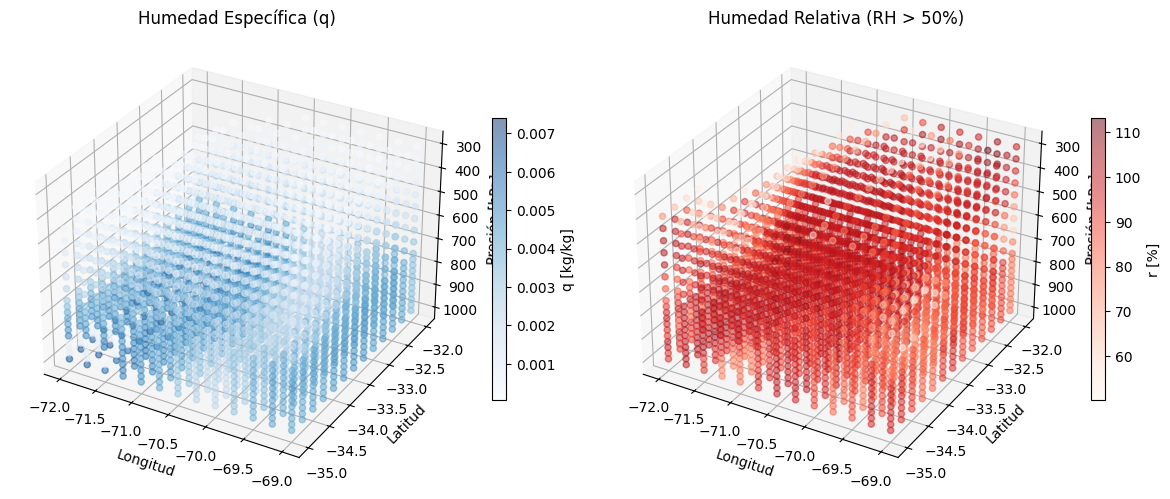

In [21]:
# Aplicar máscaras para graficar
mask_q = q_flat > q_min
mask_r = r_flat > 50

# Generar figura y ejes
fig = plt.figure(figsize=(12, 5))

# Graficar q
ax1 = fig.add_subplot(121, projection='3d')

sc1 = ax1.scatter(x_flat[mask_q], y_flat[mask_q], z_flat[mask_q],
                  c=q_flat[mask_q], cmap='Blues', alpha=0.5, marker='o')

ax1.invert_zaxis() # 1000 hPa en superficie
ax1.set_title('Humedad Específica (q)')
ax1.set_xlabel('Longitud')
ax1.set_ylabel('Latitud')
ax1.set_zlabel('Presión [hPa]')
plt.colorbar(sc1, ax=ax1, label='q [kg/kg]', shrink=0.6)

# Graficar RH
ax2 = fig.add_subplot(122, projection='3d')

sc2 = ax2.scatter(x_flat[mask_r], y_flat[mask_r], z_flat[mask_r],
                  c=r_flat[mask_r], cmap='Reds', alpha=0.5, marker='o')

ax2.invert_zaxis()
ax2.set_title('Humedad Relativa (RH > 50%)')
ax2.set_xlabel('Longitud')
ax2.set_ylabel('Latitud')
ax2.set_zlabel('Presión [hPa]')
plt.colorbar(sc2, ax=ax2, label='RH [%]', shrink=0.6)

plt.tight_layout()
plt.show()

Con estos datos, es posible calcular los valores de agua precipitable directamente utilizando la fórmula mostrada anteriormente:

¡Integración completada!


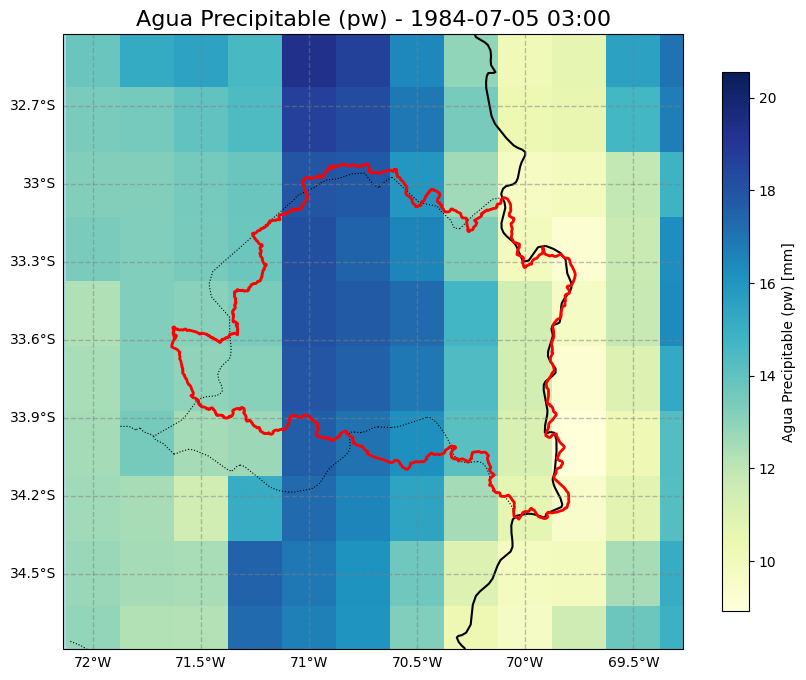

In [8]:
## Cálculo de agua precipitable por integración

# Constantes físicas
g = 9.80665  # [m/s^2]
rho_w = 1000 # [kg/m^3]

# Presión en Pascales para obtener resultado en [m]
q = ds_humedad['q'].assign_coords(level_pa=ds_humedad['level'] * 100)

# Cambiar la dimensión principal del DataArray a la nueva coordenada en Pascales
q = q.swap_dims({'level': 'level_pa'})

# Ordenar los niveles de menor a mayor presión (resultado positivo)
q = q.sortby('level_pa')

# Integrar la humedad específica con respecto a la presión
integral_q_dp = q.integrate('level_pa')

# Aplicar la fórmula: PW = (1 / (g * rho_w)) * Integral(q dP)
pw_m = integral_q_dp / (g * rho_w)

# Convertir a milímetros [mm]
pw_mm = (pw_m * 1000).squeeze()
print("¡Integración completada!")

## Gráfico de pw
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Establecer límites del mapa para la cuenca del río Maipo
bounds = shp_cuenca.total_bounds
ax.set_extent([bounds[0] - 0.5, bounds[2] + 0.5, bounds[1] - 0.5, bounds[3] + 0.5], crs=ccrs.PlateCarree())

# Capa 1: Tierra y Mar (Fondo)
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=0)

# Capa 2: Agua Precipitable
mesh = ax.pcolormesh(
    pw_mm.longitude,
    pw_mm.latitude,
    pw_mm,
    transform=ccrs.PlateCarree(),
    cmap='YlGnBu',
    zorder=1
)
plt.colorbar(mesh, ax=ax, label='Agua Precipitable (pw) [mm]', shrink=0.7, pad=0.05)

# Capa 3: Límites internacionales y regionales
ax.add_feature(cfeature.BORDERS, linewidth=1.5, edgecolor='black', zorder=2)
regiones = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lines', scale='10m', facecolor='none')
ax.add_feature(regiones, edgecolor='black', linewidth=0.8, linestyle=':', zorder=2)

# Capa 4: Límites de la cuenca
shp_cuenca.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=2, transform=ccrs.PlateCarree(), zorder=3)

# Agregar grilla
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=["bottom", "left"],
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')

ax.set_title('Agua Precipitable (pw) - 1984-07-05 03:00', fontsize=16)
plt.show()

De forma similar, se obtienen los valores de agua precipitable saturada ($pw_{sat}$) utilizando la humedad relativa:

$$pw_{sat} = \frac{1}{g\rho_w} \int_{p_1}^{p_2} \frac{q}{RH} \, dp$$


¡Integración completada!


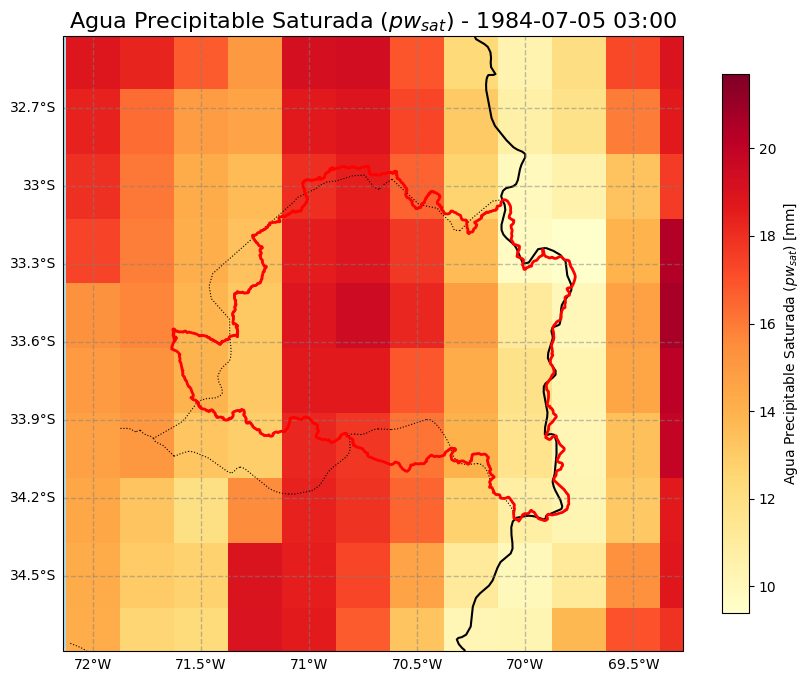

In [9]:
## Cálculo de agua precipitable saturada por integración

# Constantes físicas
g = 9.80665  # [m/s^2]
rho_w = 1000 # [kg/m^3]

# RH en rango [0,1]
rh_fraccion = ds_humedad['r'] / 100.0

# Calcular q_sat = q / RH. Se filtran valores de q despreciables (> 1e-5) para evitar división por cero
q_sat = xr.where(ds_humedad['q'] > 1e-5, ds_humedad['q'] / rh_fraccion, 0)

# Presión en Pascales para obtener resultado en [m]
q_sat_pa = q_sat.assign_coords(level_pa=ds_humedad['level'] * 100)

# Cambiar la dimensión principal del DataArray a la nueva coordenada en Pascales
q_sat_pa = q_sat_pa.swap_dims({'level': 'level_pa'})

# Ordenar los niveles de menor a mayor presión (resultado positivo)
q_sat_pa = q_sat_pa.sortby('level_pa')

# Integrar la humedad específica saturada con respecto a la presión
integral_qsat_dp = q_sat_pa.integrate('level_pa')

# Aplicar la fórmula: PW_SAT = (1 / (g * rho_w)) * Integral(q_sat dP)
pw_sat_m = integral_qsat_dp / (g * rho_w)

# Convertir a milímetros [mm]
pw_sat_mm = (pw_sat_m * 1000).squeeze()
print("¡Integración completada!")

## Gráfico de pw_sat
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Establecer límites del mapa para la cuenca del río Maipo
bounds = shp_cuenca.total_bounds
ax.set_extent([bounds[0] - 0.5, bounds[2] + 0.5, bounds[1] - 0.5, bounds[3] + 0.5], crs=ccrs.PlateCarree())

# Capa 1: Tierra y Mar (Fondo)
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=0)

# Capa 2: Agua Precipitable Saturada
mesh = ax.pcolormesh(
    pw_sat_mm.longitude,
    pw_sat_mm.latitude,
    pw_sat_mm,
    transform=ccrs.PlateCarree(),
    cmap='YlOrRd',
    zorder=1
)
plt.colorbar(mesh, ax=ax, label='Agua Precipitable Saturada ($pw_{sat}$) [mm]', shrink=0.7, pad=0.05)

# Capa 3: Límites internacionales y regionales
ax.add_feature(cfeature.BORDERS, linewidth=1.5, edgecolor='black', zorder=2)
regiones = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lines', scale='10m', facecolor='none')
ax.add_feature(regiones, edgecolor='black', linewidth=0.8, linestyle=':', zorder=2)

# Capa 4: Límites de la cuenca
shp_cuenca.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=2, transform=ccrs.PlateCarree(), zorder=3)

# Agregar grilla
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=["bottom", "left"],
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')

ax.set_title('Agua Precipitable Saturada ($pw_{sat}$) - 1984-07-05 03:00', fontsize=16)
plt.show()

Los valores de agua precipitable pueden sufrir fuertes variaciones en intervalos cortos de tiempo, por lo que es usual considerar para el cálculo de factores de maximización los **valores persistentes de 12 horas**.

Estos corresponden a los valores de agua precipitable que se mantienen de forma persistente durante una ventana de 12 horas, esto es, que están **garantizados** durante el desarrollo de la tormenta. Gráficamente esto se puede visualizar de la siguiente manera:


<>:25: SyntaxWarning:

invalid escape sequence '\,'

<>:25: SyntaxWarning:

invalid escape sequence '\,'

/tmp/ipykernel_2873/1602996135.py:25: SyntaxWarning:

invalid escape sequence '\,'



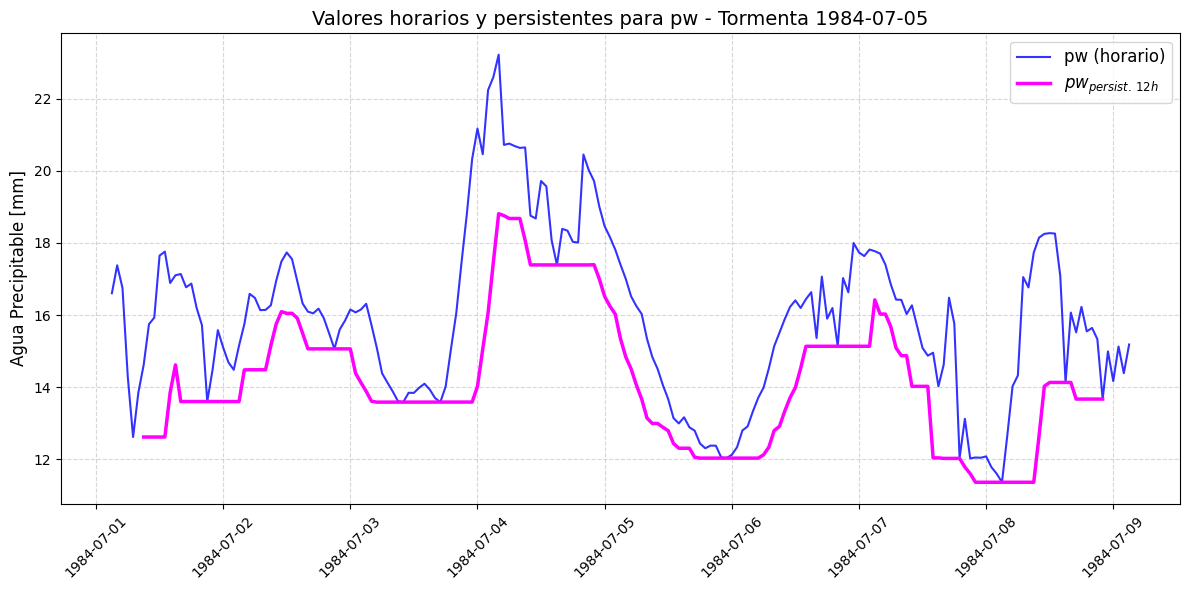

In [10]:
## Visualizar valores persistentes de 12 horas

# Colapsar dimensiones
pw_serie = ds_pw_serie['pw'].squeeze()

# Considerar únicamente una ventana de 7 días sobre la tormenta
fecha_tormenta = pd.Timestamp('1984-07-05 03:00')
fecha_inicio = fecha_tormenta - pd.Timedelta(hours=24*4)
fecha_fin = fecha_tormenta + pd.Timedelta(hours=24*4)

pw_ventana = pw_serie.sel(time=slice(fecha_inicio, fecha_fin))

# Calcular pw_persist_12h
pw_persistente = pw_ventana.rolling(time=12, center=True).min()

## Graficar

# Generar figura y ejes
fig, ax = plt.subplots(figsize=(12, 6))

# Serie horaria original en azul
ax.plot(pw_ventana.time, pw_ventana, color='blue', label='pw (horario)', linewidth=1.5, alpha=0.8)

# Serie persistente de 12h en magenta
ax.plot(pw_persistente.time, pw_persistente, color='magenta', label='$pw_{persist.\, 12h}$', linewidth=2.5)

# Configuración del gráfico
ax.set_title('Valores horarios y persistentes para pw - Tormenta 1984-07-05', fontsize=14)
ax.set_ylabel('Agua Precipitable [mm]', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=12, loc='upper right')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

De esta forma, el valor de agua precipitable disponible durante la tormenta ($pw_{obs}$) se obtiene como el máximo valor de agua precipitable persistente de 12 horas durante la tormenta y las 48 horas previas a su ocurrencia. Se considera el momento con mayor disponibilidad de humedad durante la formación de la tormenta:

<>:38: SyntaxWarning:

invalid escape sequence '\,'

<>:38: SyntaxWarning:

invalid escape sequence '\,'

/tmp/ipykernel_2873/2836665361.py:38: SyntaxWarning:

invalid escape sequence '\,'



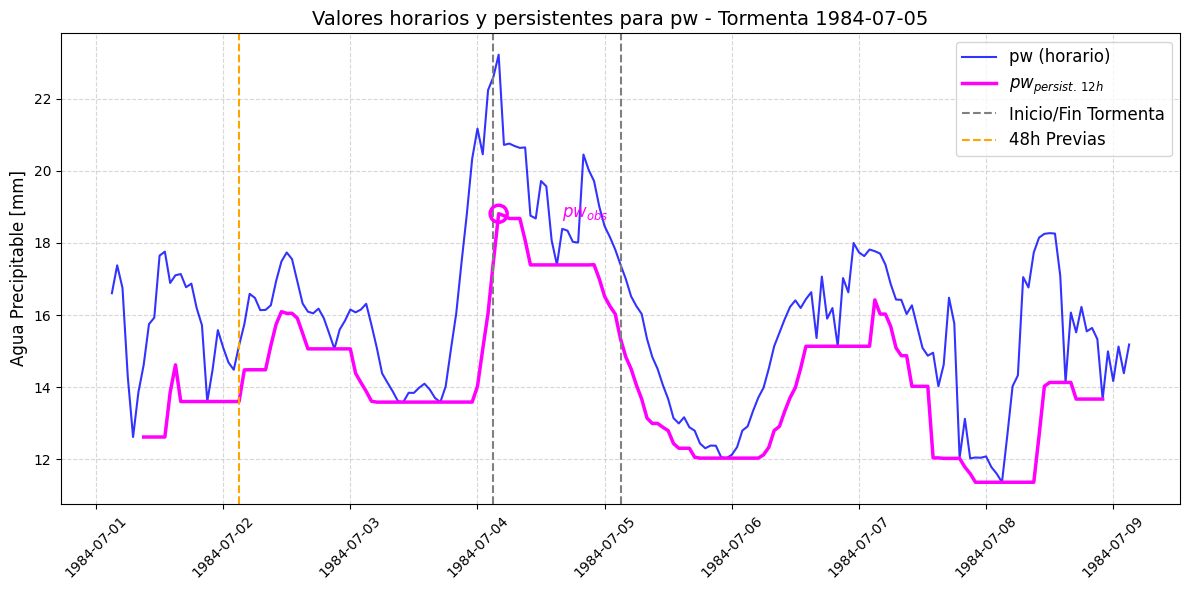

El valor máximo persistente de pw_tormenta  es: 18.81
El valor máximo persistente de pw_sat_tormenta es: 30.72 mm


In [11]:
## Visualizar valores persistentes de 12 horas

# Colapsar dimensiones
pw_serie = ds_pw_serie['pw'].squeeze()

# Considerar únicamente una ventana de 7 días sobre la tormenta
fecha_tormenta = pd.Timestamp('1984-07-05 03:00')
fecha_inicio = fecha_tormenta - pd.Timedelta(hours=24*4)
fecha_fin = fecha_tormenta + pd.Timedelta(hours=24*4)

pw_ventana = pw_serie.sel(time=slice(fecha_inicio, fecha_fin))

# Calcular pw_persist_12h
pw_persistente = pw_ventana.rolling(time=12, center=True).min()

# Fechas de la tormenta específica
inicio_tormenta = pd.Timestamp('1984-07-05 03:00') - pd.Timedelta(hours=24)
fin_tormenta = pd.Timestamp('1984-07-05 03:00')
inicio_48h_previas = inicio_tormenta - pd.Timedelta(hours=48)

# Rango para buscar pw_tormenta
ventana_busqueda = pw_persistente.sel(time=slice(inicio_48h_previas, fin_tormenta))

# Valor máximo de pw persistente
pw_tormenta_val = float(ventana_busqueda.max(skipna=True))
tiempo_pw_tormenta = ventana_busqueda.idxmax(skipna=True).values


## Graficar

# Generar figura y ejes
fig, ax = plt.subplots(figsize=(12, 6))

# Serie horaria original en azul
ax.plot(pw_ventana.time, pw_ventana, color='blue', label='pw (horario)', linewidth=1.5, alpha=0.8)

# Serie persistente de 12h en magenta
ax.plot(pw_persistente.time, pw_persistente, color='magenta', label='$pw_{persist. 12h}$', linewidth=2.5)

# Líneas verticales para inicio y fin de la tormenta
ax.axvline(inicio_tormenta, color='gray', linestyle='--', linewidth=1.5, label='Inicio/Fin Tormenta')
ax.axvline(fin_tormenta, color='gray', linestyle='--', linewidth=1.5)

# Línea vertical para 48h previas
ax.axvline(inicio_48h_previas, color='orange', linestyle='--', linewidth=1.5, label='48h Previas')

# Destacar el valor máximo con un círculo hueco
ax.scatter(tiempo_pw_tormenta, pw_tormenta_val,
           facecolors='none', edgecolors='magenta', s=150, linewidth=2.5, zorder=5)

# Agregar texto para identificar el máximo
desfase_tiempo = pd.Timedelta(hours=12)
ax.text(tiempo_pw_tormenta + desfase_tiempo, pw_tormenta_val,
        r'$pw_{obs}$', color='magenta', fontsize=12, fontweight='bold', va='center', ha='left')

# Configuración del gráfico
ax.set_title('Valores horarios y persistentes para pw - Tormenta 1984-07-05', fontsize=14)
ax.set_ylabel('Agua Precipitable [mm]', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=12, loc='upper right')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

print(f'El valor máximo persistente de pw_tormenta  es: {pw_tormenta_val:.2f}')


## Repetir el cálculo para pw_sat tormenta

# Colapsar dimensiones para pw_sat
pwsat_serie = ds_pw_serie['pw_sat'].squeeze()

# Considerar únicamente una ventana de 8 días alrededor de la tormenta
fecha_tormenta = pd.Timestamp('1984-07-05 03:00')
fecha_inicio = fecha_tormenta - pd.Timedelta(hours=24*4)
fecha_fin = fecha_tormenta + pd.Timedelta(hours=24*4)

pwsat_ventana = pwsat_serie.sel(time=slice(fecha_inicio, fecha_fin))

# Calcular pw_sat_persist_12h
pwsat_persistente = pwsat_ventana.rolling(time=12, center=True).min()

# Fechas de la tormenta específica
inicio_tormenta = pd.Timestamp('1984-07-05 03:00') - pd.Timedelta(hours=24)
fin_tormenta = pd.Timestamp('1984-07-05 03:00')
inicio_48h_previas = inicio_tormenta - pd.Timedelta(hours=48)

# Rango para buscar pwsat_tormenta
ventana_busqueda_sat = pwsat_persistente.sel(time=slice(inicio_48h_previas, fin_tormenta))

# Valor máximo de pw_sat persistente y su momento exacto
pwsat_tormenta_val = float(ventana_busqueda_sat.max(skipna=True))
tiempo_pwsat_tormenta = ventana_busqueda_sat.idxmax(skipna=True).values

print(f"El valor máximo persistente de pw_sat_tormenta es: {pwsat_tormenta_val:.2f} mm")

Por otro lado, el agua precipitable máxima durante la tormenta ($pw_{max}$) se obtiene como el mínimo entre el agua precipitable saturada durante la tormenta ($pw_{sat\, obs}$, considerando de igual forma el valormáximo persistente de 12 horas en la misma ventana), y el agua precipitable persistente de 12 horas con 100 años de periodo de retorno para una ventana de 30 días centrada en la fecha de ocurrencia de la tormenta ($pw_{T=100}$):

$pw_{max} = min\{pw_{sat\, obs}; pw_{T=100}\}$

El valor de $pw_{T=100}$ corresponde a un valor de agua precipitable con probabilidad de excedencia igual a $1/100$, calculado a través de un ajuste probabilístico para los maximos anuales de $pw_{persist.\, 12h}$ para la ventana de 30 días centrada en el día de la tormenta de interés:

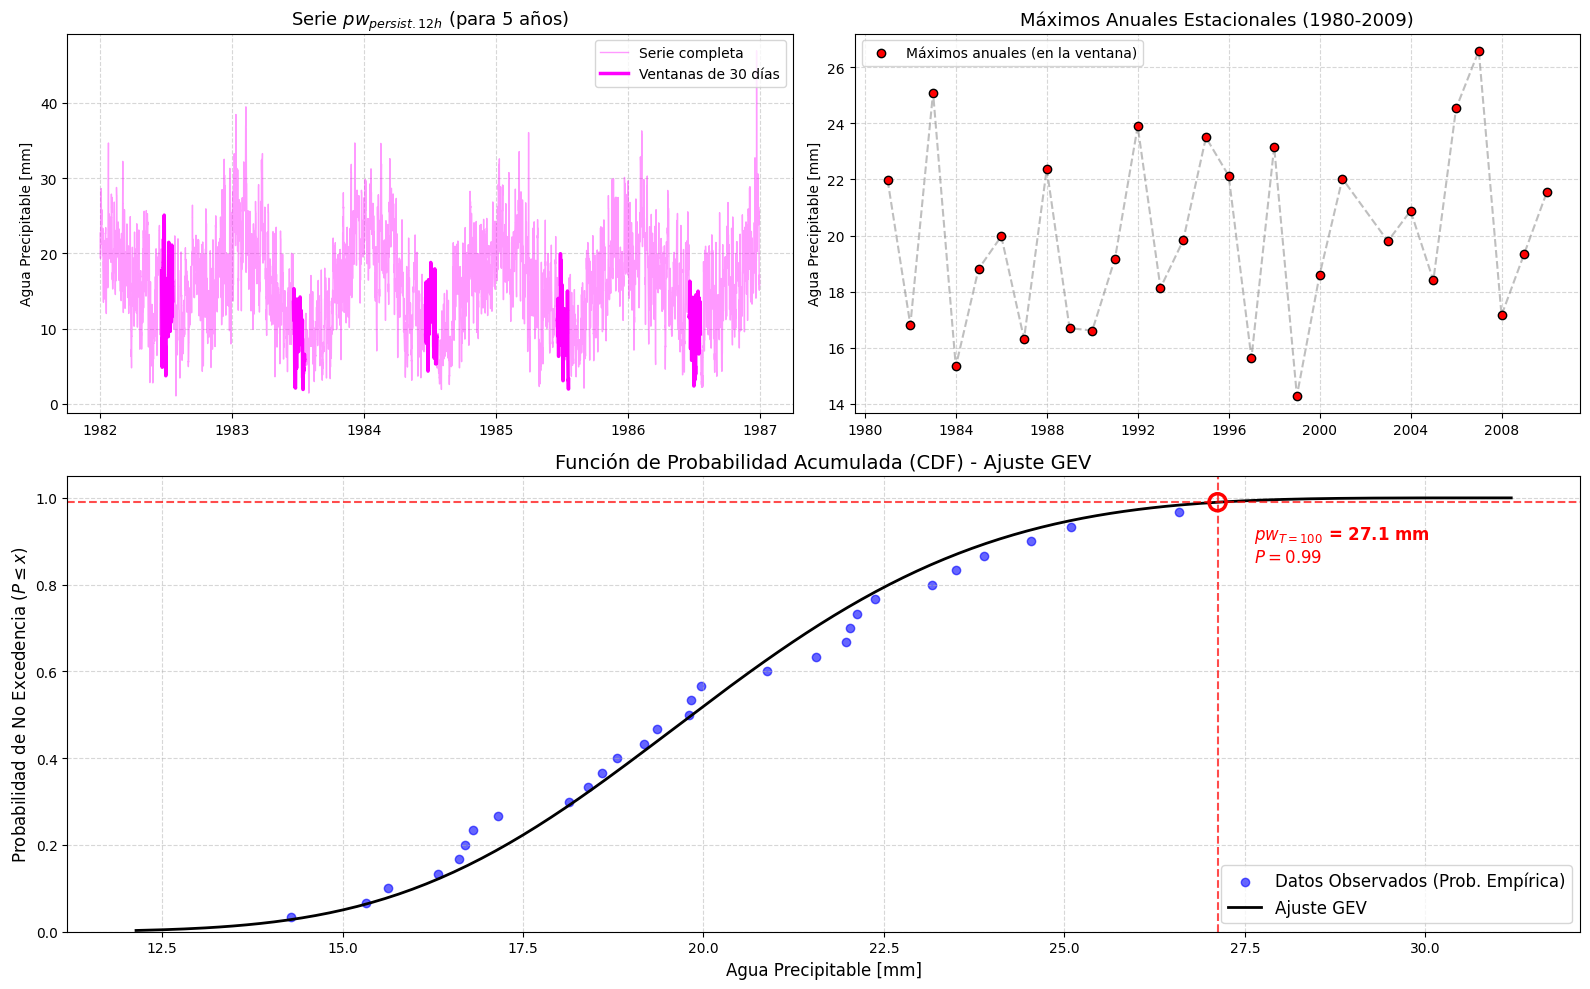

El valor de pw para T=100 años es: 27.12 mm


In [12]:
# 1. Definición de ventanas y filtrado
# Asumimos que pw_persistente ya está calculado para toda la serie histórica (1980-2009)
pw_persistente = ds_pw_serie['pw'].rolling(time=12, center=True).min()

# Crear máscara para 30 días centrados en el 5 de julio (aprox. 20 de junio al 20 de julio)
mes = pw_persistente['time'].dt.month
dia = pw_persistente['time'].dt.day
mask_ventana = ((mes == 6) & (dia >= 20)) | ((mes == 7) & (dia <= 20))

# Aplicar el filtro: todo lo que esté fuera de la ventana se vuelve NaN
pw_filtrado = pw_persistente.where(mask_ventana)

# 2. Extracción de Máximos Anuales para el ajuste estadístico (usando toda la serie histórica)
# Al agrupar por año sobre la serie filtrada, obtenemos el máximo anual solo para esa ventana
maximos_anuales = pw_filtrado.resample(time='1YE').max(skipna=True).dropna('time')

# 3. Ajuste de la Distribución GEV (Generalized Extreme Value)
datos_extremos = maximos_anuales.values
# genextreme.fit devuelve 3 parámetros: forma (c), locación (loc) y escala (scale)
forma, loc, escala = genextreme.fit(datos_extremos)

# Calcular el valor para T=100 años (Probabilidad de no excedencia P = 0.99)
prob_100 = 0.99
pw_T100 = genextreme.ppf(prob_100, forma, loc=loc, scale=escala)

# 4. Preparación de datos para los gráficos de la Fila 1 (Tramo de 5 años: 1982-1986)
fecha_ini_5y = '1982-01-01'
fecha_fin_5y = '1986-12-31'
pw_5y_completo = pw_persistente.sel(time=slice(fecha_ini_5y, fecha_fin_5y))
pw_5y_ventana = pw_filtrado.sel(time=slice(fecha_ini_5y, fecha_fin_5y))

# --- GENERACIÓN DE LA FIGURA MÚLTIPLE ---
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 2, height_ratios=[1, 1.2]) # Fila inferior un poco más alta para la GEV

# Subplot 1: Serie de 5 años con ventanas destacadas
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(pw_5y_completo.time, pw_5y_completo, color='magenta', alpha=0.4, linewidth=1, label='Serie completa')
ax1.plot(pw_5y_ventana.time, pw_5y_ventana, color='magenta', alpha=1.0, linewidth=2.5, label='Ventanas de 30 días')
ax1.set_title('Serie $pw_{persist. 12h}$ (para 5 años)', fontsize=13)
ax1.set_ylabel('Agua Precipitable [mm]')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right')

# Formato de fechas para ax1
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Subplot 2: Serie histórica de máximos anuales
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(maximos_anuales.time, maximos_anuales, color='gray', linestyle='--', alpha=0.5)
ax2.scatter(maximos_anuales.time, maximos_anuales, color='red', edgecolor='black', zorder=5, label='Máximos anuales (en la ventana)')
ax2.set_title('Máximos Anuales Estacionales (1980-2009)', fontsize=13)
ax2.set_ylabel('Agua Precipitable [mm]')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()

# Subplot 3: Curva GEV y P=0.99 (Abarca toda la fila inferior)
ax3 = fig.add_subplot(gs[1, :])

# Generar puntos teóricos para dibujar la curva suave
x_teorico = np.linspace(min(datos_extremos) * 0.85, pw_T100 * 1.15, 200)
cdf_teorica = genextreme.cdf(x_teorico, forma, loc=loc, scale=escala)

# Probabilidad empírica de los datos usando la fórmula de Weibull: i / (n+1)
datos_ordenados = np.sort(datos_extremos)
prob_empirica = np.arange(1, len(datos_extremos) + 1) / (len(datos_extremos) + 1)

# Graficar CDF empírica vs teórica
ax3.scatter(datos_ordenados, prob_empirica, color='blue', alpha=0.6, label='Datos Observados (Prob. Empírica)')
ax3.plot(x_teorico, cdf_teorica, color='black', linewidth=2, label='Ajuste GEV')

# Líneas de referencia para T=100
ax3.axhline(prob_100, color='red', linestyle='--', alpha=0.7)
ax3.axvline(pw_T100, color='red', linestyle='--', alpha=0.7)
ax3.scatter(pw_T100, prob_100, facecolors='none', edgecolors='red', s=150, linewidth=2.5, zorder=5)

# Textos y configuraciones finales
ax3.text(pw_T100 + 0.5, prob_100 - 0.05, f'$pw_{{T=100}}$ = {pw_T100:.1f} mm\n$P = 0.99$',
         color='red', fontsize=12, fontweight='bold', va='top', ha='left')

ax3.set_title('Función de Probabilidad Acumulada (CDF) - Ajuste GEV', fontsize=14)
ax3.set_xlabel('Agua Precipitable [mm]', fontsize=12)
ax3.set_ylabel(r'Probabilidad de No Excedencia ($P \leq x$)', fontsize=12)
ax3.set_ylim(0, 1.05)
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.legend(loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()

print(f"El valor de pw para T=100 años es: {pw_T100:.2f} mm")

* **NOTA:** El cálculo espacial de $pw_{T=100}$ es considerablemente costoso computacionalmente, ya que se debe realizar para cada día del año en cada celda de la zona de estudio.

De esta forma, al obtener $pw_{obs}$, $pw_{sat\, obs}$ y $pw_{T=100}$,es posible obtener la maximización de la tormenta de ejemplo:

$pw_{obs} = 18.81 [mm]$

$pw_{sat\, obs} = 30.72 [mm]$

$pw_{max} = min\{pw_{sat\, obs};\; pw_{T=100}\} = min\{30.72\,[mm];\; 27.12\,[mm]\} = 27.12\, [mm]$

Así, el factor de maximización para la tormenta de ejemplo corresponde a:

**$r = \frac{pw_{max}}{pw_{obs}} = \frac{27.12}{18.81} = 1.44$**

**Método Local − Maximización de Humedad**

Con estos valores, es posible volver a la curva P-A y realizar la maximización para obtener un estimado de la PMP espacial en la cuenca del río Maipo:

$PMP_{P-A} = PA\cdot r$

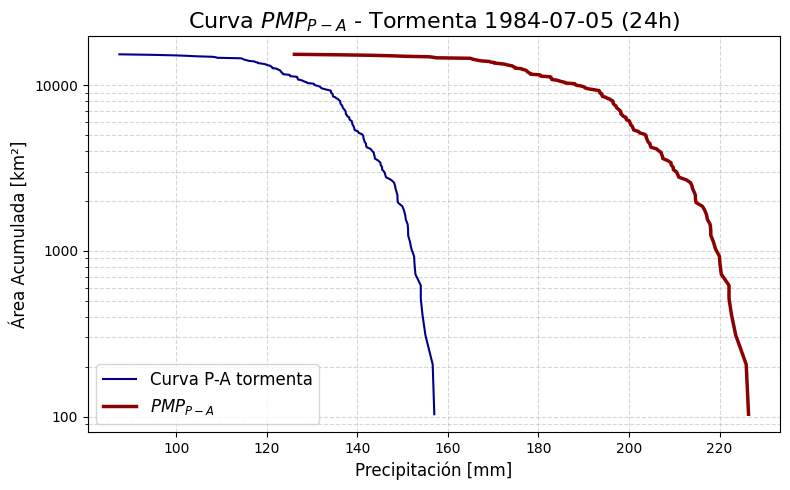

In [13]:
## Factor de maximizacion

r = np.min([pwsat_tormenta_val, pw_T100]) / pw_tormenta_val


## Maximización curva P-A
PMP_PA = pr_sorted * r


## Generar gráfico de curva PMP P-A

# Generar figura y ejes
fig, ax5 = plt.subplots(figsize=(8, 5))

ax5.plot(pr_sorted, area_acumulada, color='darkblue', linewidth=1.5, label='Curva P-A tormenta')
ax5.plot(PMP_PA, area_acumulada, color='darkred', linewidth=2.5, label='$PMP_{P-A}$')

ax5.set_xlabel('Precipitación [mm]', fontsize=12)
ax5.set_ylabel('Área Acumulada [km²]', fontsize=12)
ax5.set_title('Curva $PMP_{P-A}$ - Tormenta 1984-07-05 (24h)', fontsize=16)
ax5.legend(fontsize=12, loc='best')

# Escala logarítmica para el Eje Y
ax5.set_yscale('log')
ax5.yaxis.set_major_formatter(ticker.ScalarFormatter())

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


Para facilitar la explicación del procedimiento, este resultado se obtuvo utilizando un factor de maximización calculado con la humedad de una celda arbitraria y considerando una única tormenta. A pesar de esto, esta ya corresponde a una aproximación al valor de la PMP a nivel de cuenca.

Para una mejor estimación, es necesario:
* Repetir el procedimiento mostrado con más tormentas para generar una envolvente de curvas $PMP_{P-A}$ que represente de mejor manera la variabilidad espacial de las precipitaciones extremas.
* Utilizar el factor de maximización más alto encontrado entre todas las celdas de la cuenca (en cada trormenta, calcular R en cada celda de la cuenca y utilizar el mayor valor obtenido para la maximización).
* Repetir el procedimiento para duraciones de 24, 48 y 72 horas, con el fin de obtener una relación profundidad-duración-área (PDA).


**Obtención PMP − Envolventes**

Tormenta 1980-04-07: r_max = 1.138
Tormenta 1982-06-23: r_max = 1.173
Tormenta 1984-07-01: r_max = 1.427
Tormenta 1987-07-12: r_max = 1.177
Tormenta 1997-06-19: r_max = 1.332
Tormenta 2000-06-11: r_max = 1.560
Tormenta 2001-07-16: r_max = 0.000
Tormenta 2002-06-01: r_max = 1.460


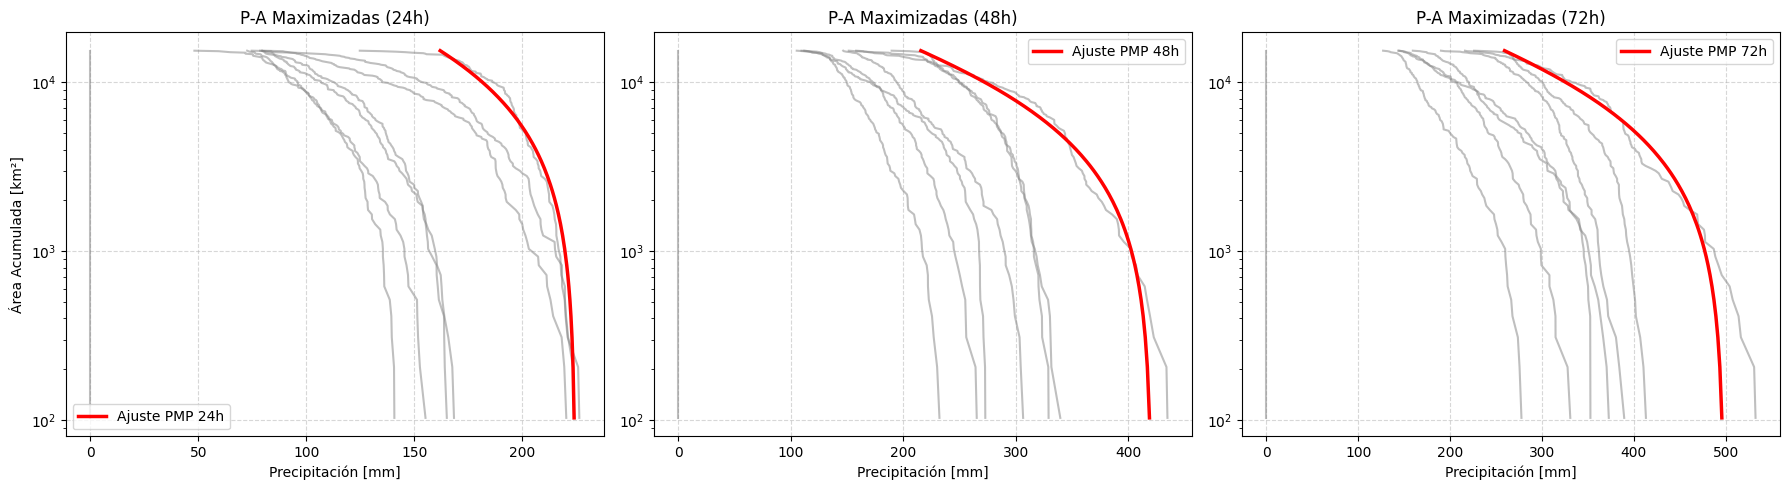

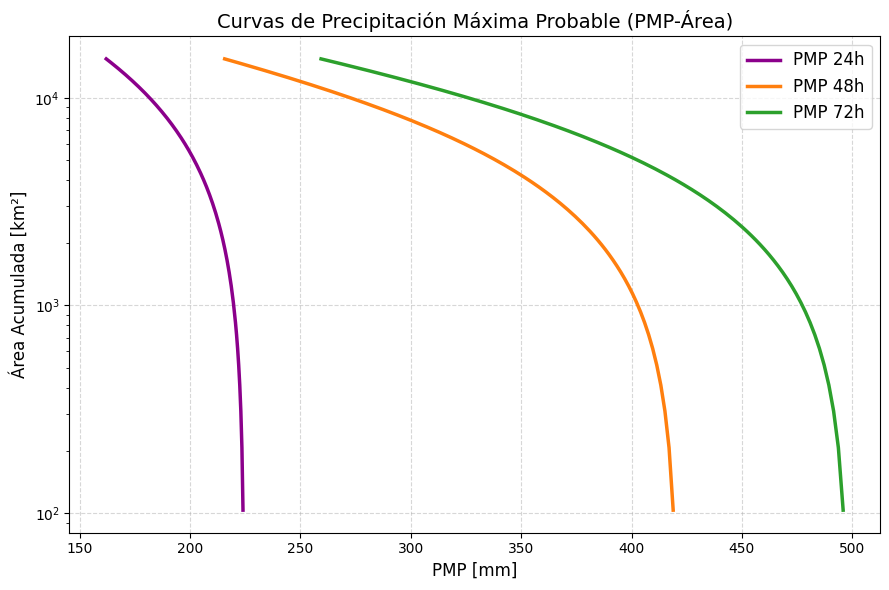

In [28]:
### Maximización de las tormentas de la lista

# Función para verificar compatibilidad espacial

def preparar_ds_espacial(ds, x_dim, y_dim):
    ds = ds.rio.write_crs("EPSG:4326")
    if x_dim in ds.dims:
        ds = ds.rio.set_spatial_dims(x_dim=x_dim, y_dim=y_dim)
    return ds

# Preparar las dimensiones de todos los datasets
ds_pw_tormentas = preparar_ds_espacial(ds_pw_tormentas, "longitude", "latitude")
ds_pw_100 = preparar_ds_espacial(ds_pw_100, "longitude", "latitude")
ds_pr = preparar_ds_espacial(ds_pr, "lon", "lat")

## Factor de maximización para cada tormenta de la lista:
factores_r = {}

for tormenta in ds_pr.tormenta.values:
    # Obtener el Día del Año (DOY) para extraer el pw_T100 correspondiente
    doy = pd.Timestamp(str(tormenta)).dayofyear

    # Extraer los campos espaciales específicos
    pw_storm = ds_pw_tormentas.sel(tormenta=tormenta)
    pw_100_storm = ds_pw_100['pw_100'].sel(dia=doy)

    # Calcular los valores persistentes de 12 horas (center=False para consistencia con pr)
    pw_roll = pw_storm['pw'].rolling(time=12, center=False).min()
    pwsat_roll = pw_storm['pw_sat'].rolling(time=12, center=False).min()

    # Extraer el valor máximo de esta persistencia durante la ventana del evento
    pw_max = pw_roll.max(dim='time')
    pwsat_max = pwsat_roll.max(dim='time')

    # Calcular la matriz espacial R
    r_grid = np.minimum(pwsat_max, pw_100_storm) / pw_max

    # Recortar R a la cuenca y extraer el escalar máximo
    r_grid = preparar_ds_espacial(r_grid, "longitude", "latitude")
    r_cuenca = r_grid.rio.clip(shp_cuenca.geometry, shp_cuenca.crs, drop=True)

    factores_r[tormenta] = float(r_cuenca.max(skipna=True))
    print(f"Tormenta {tormenta}: r_max = {factores_r[tormenta]:.3f}")


## Curvas PA y maximización

# Recortar el dataset ds_pr
clipped_ds_pr = ds_pr.rio.clip(shp_cuenca.geometry, shp_cuenca.crs, drop=True)
pr_cuenca = clipped_ds_pr['pr']

# Calcular área de las celdas
res_deg = abs(float(ds_pr.lon[1] - ds_pr.lon[0]))
lat_media = np.abs(float(pr_cuenca.lat.mean()))
area_celda_km2 = (res_deg * 111.32 * np.cos(np.radians(lat_media))) * (res_deg * 111.32)

duraciones = [24, 48, 72]
pda_maximizadas = {d: [] for d in duraciones}
areas_km2 = None

# Iterar para cada duración y tormenta de la lista
for d in duraciones:
    for t in pr_cuenca.tormenta.values:
        # Extraer celdas válidas y ordenar de mayor a menor
        pr_vals = pr_cuenca.sel(tormenta=t, duracion=d).values.flatten()
        pr_vals = pr_vals[~np.isnan(pr_vals)]
        pr_sorted = np.sort(pr_vals)[::-1]

        # Generar el eje de área en la primera iteración
        if areas_km2 is None:
            areas_km2 = np.arange(1, len(pr_sorted) + 1) * area_celda_km2

        # Maximizar y almacenar
        pda_maximizadas[d].append(pr_sorted * factores_r[t])


### Graficar

# Funciones para ajuste suavizado
def exp_decay(a, P0, k):
    return P0 * np.exp(-k * a)

def fit_exponential_envelope(pda_curve):
    N = len(pda_curve)
    a = np.arange(1, N + 1) / N  # Fracción de área (0–1)
    mask = ~np.isnan(pda_curve)
    a_clean, p_clean = a[mask], pda_curve[mask]

    try:
        popt, _ = curve_fit(exp_decay, a_clean, p_clean, p0=[p_clean[0], 2.0], maxfev=10000)
        return exp_decay(a, *popt)
    except:
        return np.full_like(a, np.nan)


## Gráfico 1: Curvas individuales y Envolvente por duración

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
curvas_ajustadas = {}

for i, d in enumerate(duraciones):
    ax = axes[i]
    matriz_curvas = np.vstack(pda_maximizadas[d])

    # Envolvente máxima
    envolvente_max = np.max(matriz_curvas, axis=0)

    # Graficar individuales
    for curva in pda_maximizadas[d]:
        ax.plot(curva, areas_km2, color='gray', alpha=0.5) # Invert axes

    # Calcular y graficar ajuste exponencial
    curva_suave = fit_exponential_envelope(envolvente_max)
    curvas_ajustadas[d] = curva_suave

    ax.plot(curva_suave, areas_km2, color='red', linewidth=2.5, label=f'Ajuste PMP {d}h')
    ax.set_title(f'P-A Maximizadas ({d}h)')
    ax.set_xlabel('Precipitación [mm]')
    if i == 0: ax.set_ylabel('Área Acumulada [km²]')
    ax.set_yscale('log')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.show()

print('\n\n')

## Gráfico 2: Curvas PMP (PDA) Finales
fig2, ax_final = plt.subplots(figsize=(9, 6))
colores = {24: '#8B008B', 48: '#ff7f0e', 72: '#2ca02c'}

for d in duraciones:
    ax_final.plot(curvas_ajustadas[d], areas_km2, color=colores[d], linewidth=2.5, label=f'PMP {d}h')

ax_final.set_title('Curvas de Precipitación Máxima Probable (PMP-Área)', fontsize=14)
ax_final.set_xlabel('PMP [mm]', fontsize=12)
ax_final.set_ylabel('Área Acumulada [km²]', fontsize=12)
ax_final.set_yscale('log')
ax_final.grid(True, linestyle='--', alpha=0.5)
ax_final.legend(fontsize=12)
plt.tight_layout()
plt.show()
